In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import pickle
import math
from nltk.tokenize import word_tokenize, sent_tokenize
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Import các file model và metrics bạn đã chuẩn bị
# Lưu ý: Hãy đổi tên Class/Function (ví dụ: LogisticRegression, accuracy) 
# cho khớp chính xác với những gì bạn đã định nghĩa trong file .py
from models.logictisregression import LogisticRegressionM
from models.naive_bayes import MultinomialNaiveBayes
from models.svm import LinearSVM
from utils.metrics import compute_evaluation

In [36]:
# Tải dữ liệu từ file bạn đã upload
# Giả sử file có 2 cột chính là 'text' (chứa nội dung) và 'label' (chứa nhãn spam/ham)
# Nếu tên cột trong file CSV của bạn khác, hãy thay đổi tên cột ở dòng rename bên dưới.
df = pd.read_csv('data/email_spam.csv', encoding='latin-1')

# Đổi tên cột cho chuẩn hóa nếu cần (VD: v1 -> label, v2 -> text)
if 'v1' in df.columns and 'v2' in df.columns:
    df = df.rename(columns={'v1': 'label', 'v2': 'text'})

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       5572 non-null   object
 1   text        5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


### Khám phá dữ liệu EDA

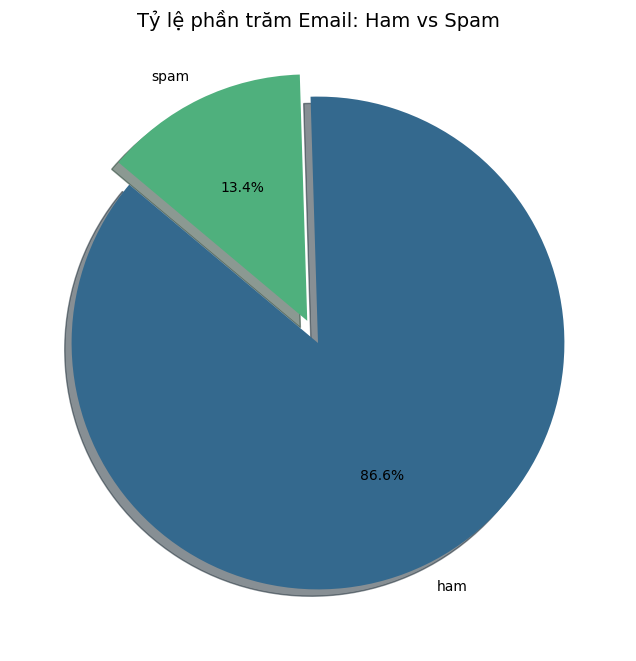

In [31]:
plt.figure(figsize=(8, 8))
plt.pie(
    df["label"].value_counts(), 
    labels=df["label"].unique(),      
    autopct='%1.1f%%',              
    startangle=140,                 
    colors=['#34698e', '#4fb07d'],  
    explode=(0, 0.1),               
    shadow=True                     
)

plt.title('Tỷ lệ phần trăm Email: Ham vs Spam', fontsize=14)
plt.show()

--- 1. KHÁM PHÁ DỮ LIỆU ---
Tổng quan dữ liệu: 5169 dòng, 5 cột

Kiểm tra giá trị thiếu:
 label            0
text             0
Unnamed: 2    5126
Unnamed: 3    5159
Unnamed: 4    5164
dtype: int64

Số lượng dữ liệu trùng lặp: 0


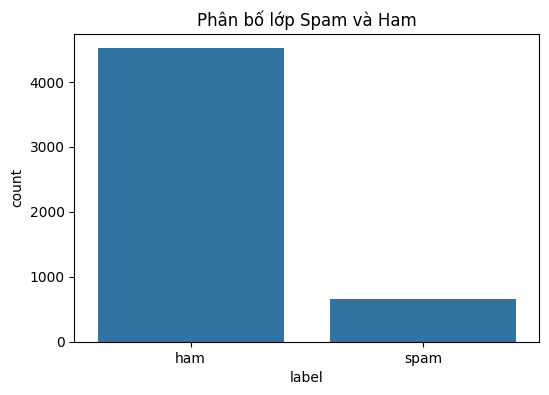

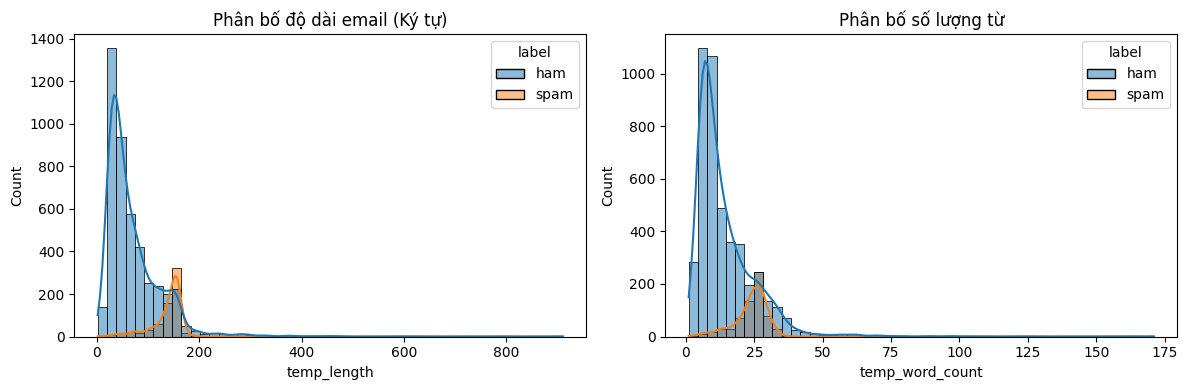


Trung bình ký tự đặc biệt mỗi email: 4.30

Top 10 từ xuất hiện nhiều nhất toàn tập dữ liệu:
 - 'i': 2095 lần
 - 'to': 2055 lần
 - 'you': 1832 lần
 - 'a': 1281 lần
 - 'the': 1223 lần
 - 'and': 919 lần
 - 'u': 890 lần
 - 'in': 785 lần
 - 'is': 766 lần
 - 'my': 676 lần


In [43]:

# Kiểm tra giá trị thiếu
print("\nKiểm tra giá trị thiếu:\n", df.isnull().sum())

# Kiểm tra dữ liệu trùng lặp
duplicates = df.duplicated().sum()
print(f"\nSố lượng dữ liệu trùng lặp: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates(keep='first')
    print(f"Đã xóa trùng lặp. Dữ liệu còn lại: {df.shape[0]} dòng")

# Phân bố lớp Spam/Ham
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Phân bố lớp Spam và Ham')
plt.show()

# Phân tích độ dài email & số lượng từ
df['temp_length'] = df['text'].apply(len)
df['temp_word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['temp_special_chars'] = df['text'].apply(lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', str(x))))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='temp_length', hue='label', bins=50, kde=True)
plt.title('Phân bố độ dài email (Ký tự)')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='temp_word_count', hue='label', bins=50, kde=True)
plt.title('Phân bố số lượng từ')
plt.tight_layout()
plt.show()
print(f"\nTrung bình ký tự đặc biệt mỗi email: {df['temp_special_chars'].mean():.2f}")
# Xóa các cột tạm dùng cho EDA
df = df.drop(columns=['temp_length', 'temp_word_count', 'temp_special_chars'])

In [96]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 0. BƯỚC MỚI: Xóa toàn bộ ký tự non-ASCII (như å, õ, ă, ê, các biểu tượng lạ...)
    # Chuỗi "thatåõs" sẽ tự động biến thành "thats"
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # 1. Loại bỏ HTML Tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 2. Loại bỏ URL
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    
    # 3. Loại bỏ chữ số
    text = re.sub(r'\d+', ' ', text)
    
    # 4. In thường
    text = text.lower()
    
    # 5. Loại bỏ dấu câu
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 6. Tách từ
    tokens = text.split()
    
    # 7. Loại bỏ Stopwords và ký tự đơn lẻ
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    
    return ' '.join(tokens)

df['message_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['clean_message'] = df['text'].apply(preprocess_text)



In [97]:
df.head(20)


,label,text,message_length,word_count,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,go jurong point crazy available bugis great wo...
1,ham,Ok lar... Joking wif u oni...,29,6,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,49,11,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,nah dont think goes usf lives around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,148,32,freemsg hey darling weeks word back id like fu...
6,ham,Even my brother is not like to speak with me. ...,77,16,even brother like speak treat like aids patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,160,26,per request melle melle oru minnaminunginte nu...
8,spam,WINNER!! As a valued network customer you have...,158,26,winner valued network customer selected receiv...
9,spam,Had your mobile 11 months or more? U R entitle...,154,29,mobile months entitled update latest colour mo...
